# ApexPlanet Data Analytics Internship — Task 4
## Advanced Analytics

**Dataset:** `Superstore_Cleaned_Task1.csv`

### Objectives
- Perform descriptive and statistical analysis.
- Test relationships between important business variables.
- Segment customers using K-Means clustering.
- Evaluate clusters using the Elbow Method and Silhouette Score.
- Build and compare Linear Regression and Random Forest sales prediction models.
- Evaluate models using MAE, RMSE, and R².
- Generate actionable business recommendations.

In [1]:
# Install packages if required
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")

df = pd.read_csv("Superstore_Cleaned_Task1.csv", encoding="utf-8")
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
if "Ship_Date" in df.columns:
    df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (8399, 21)


,Row_ID,Order_ID,Order_Date,Order_Priority,Order_Quantity,Sales,Discount,Ship_Mode,Profit,Unit_Price,...,Customer_Name,Province,Region,Customer_Segment,Product_Category,Product_Sub_Category,Product_Name,Product_Container,Product_Base_Margin,Ship_Date
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-07-12
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30


## 1. Descriptive Statistical Analysis

In [2]:
numeric_cols = [c for c in ["Sales","Profit","Order_Quantity","Discount","Unit_Price","Shipping_Cost","Product_Base_Margin"] if c in df.columns]
statistical_summary = df[numeric_cols].describe().T
statistical_summary["skewness"] = df[numeric_cols].skew()
statistical_summary["kurtosis"] = df[numeric_cols].kurtosis()
display(statistical_summary.round(4))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Sales,8399.0,1775.8782,3585.0505,2.24,143.195,449.42,1709.32,89061.05,5.3870,60.9284
Profit,8399.0,181.1844,1196.6534,-14140.70,-83.315,-1.50,162.75,27220.69,3.6472,67.3497
Order_Quantity,8399.0,25.5717,14.4811,1.00,13.000,26.00,38.00,50.00,-0.0173,-1.2080
Discount,8399.0,0.0497,0.0318,0.00,0.020,0.05,0.08,0.25,0.0739,-0.9594
Unit_Price,8399.0,89.3463,290.3544,0.99,6.480,20.99,85.99,6783.02,14.1278,271.1687
Shipping_Cost,8399.0,12.8386,17.2641,0.49,3.300,6.07,13.99,164.73,2.5538,7.7516
Product_Base_Margin,8399.0,0.5126,0.1351,0.35,0.380,0.52,0.59,0.85,0.5602,-0.6442


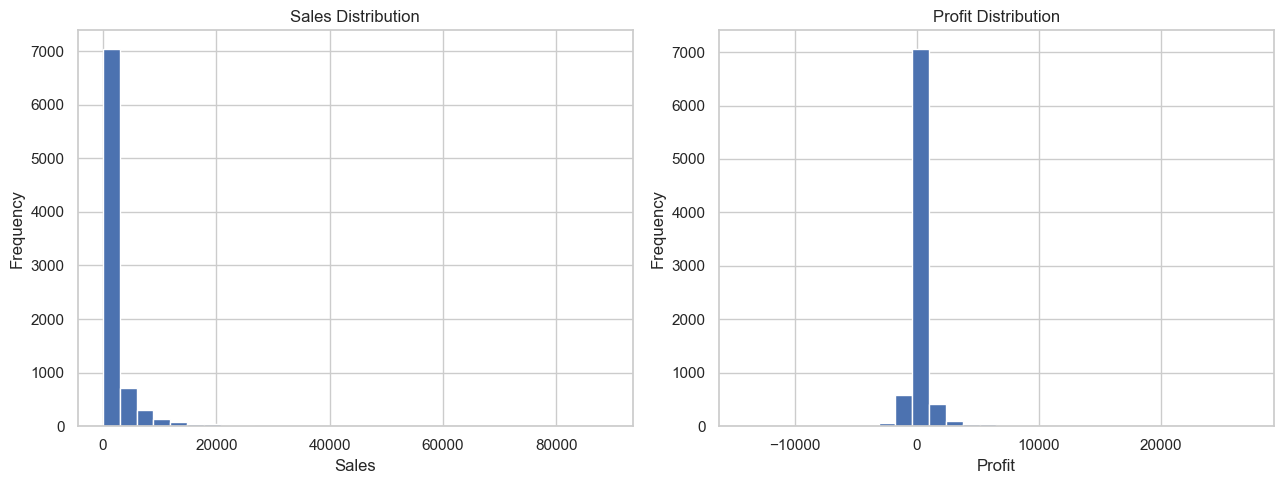

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df["Sales"].dropna(), bins=30)
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Frequency")
axes[1].hist(df["Profit"].dropna(), bins=30)
axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("Profit")
axes[1].set_ylabel("Frequency")
plt.tight_layout(); plt.show()

## 2. Hypothesis Testing

In [4]:
corr_data = df[["Sales","Profit"]].dropna()
r, p_value = stats.pearsonr(corr_data["Sales"], corr_data["Profit"])
print(f"Pearson correlation coefficient (r): {r:.4f}")
print(f"P-value: {p_value:.6g}")
print("Statistically significant at 5%:", p_value < 0.05)

Pearson correlation coefficient (r): 0.5820
P-value: 0
Statistically significant at 5%: True


In [5]:
if "Customer_Segment" in df.columns:
    counts = df["Customer_Segment"].value_counts()
    if len(counts) >= 2:
        a_name, b_name = counts.index[:2]
        a = df.loc[df["Customer_Segment"] == a_name, "Profit"].dropna()
        b = df.loc[df["Customer_Segment"] == b_name, "Profit"].dropna()
        t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
        print(f"Segments compared: {a_name} vs {b_name}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {t_p:.6g}")
        print("Statistically significant at 5%:", t_p < 0.05)

Segments compared: Corporate vs Home Office
T-statistic: 1.1912
P-value: 0.233647
Statistically significant at 5%: False


## 3. Customer Segmentation — RFM-Style Features

In [6]:
analysis_date = df["Order_Date"].max() + pd.Timedelta(days=1)
customer_features = df.groupby("Customer_Name").agg(
    Last_Order_Date=("Order_Date","max"),
    Frequency=("Order_ID","nunique"),
    Monetary=("Sales","sum"),
    Total_Profit=("Profit","sum"),
    Avg_Discount=("Discount","mean"),
    Total_Quantity=("Order_Quantity","sum")
).reset_index()
customer_features["Recency"] = (analysis_date - customer_features["Last_Order_Date"]).dt.days
cluster_cols = ["Recency","Frequency","Monetary","Total_Profit","Avg_Discount","Total_Quantity"]
X_cluster = customer_features[cluster_cols].fillna(customer_features[cluster_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
display(customer_features.head())

,Customer_Name,Last_Order_Date,Frequency,Monetary,Total_Profit,Avg_Discount,Total_Quantity,Recency
0,Aaron Bergman,2011-05-28,5,11630.5900,3025.84,0.032857,168,583
1,Aaron Hawkins,2011-12-29,9,27690.7255,5961.41,0.056667,370,368
2,Aaron Smayling,2012-01-19,8,8835.3235,2114.40,0.042857,303,347
3,Adam Bellavance,2012-10-02,8,11577.5800,-181.94,0.045000,333,90
4,Adam Hart,2012-12-11,18,26114.2645,4071.84,0.054444,506,20


## 4. K-Means Cluster Evaluation

In [7]:
inertias=[]; silhouette_scores=[]; k_values=range(2,9)
for k in k_values:
    model=KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
cluster_evaluation=pd.DataFrame({"k":list(k_values),"Inertia":inertias,"Silhouette_Score":silhouette_scores})
display(cluster_evaluation.round(4))

C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,k,Inertia,Silhouette_Score
0,2,3279.7106,0.3212
1,3,2707.8929,0.2409
2,4,2357.7676,0.2293
3,5,2082.6290,0.2198
4,6,1872.3268,0.2222
5,7,1721.2777,0.2178
6,8,1614.7152,0.1921


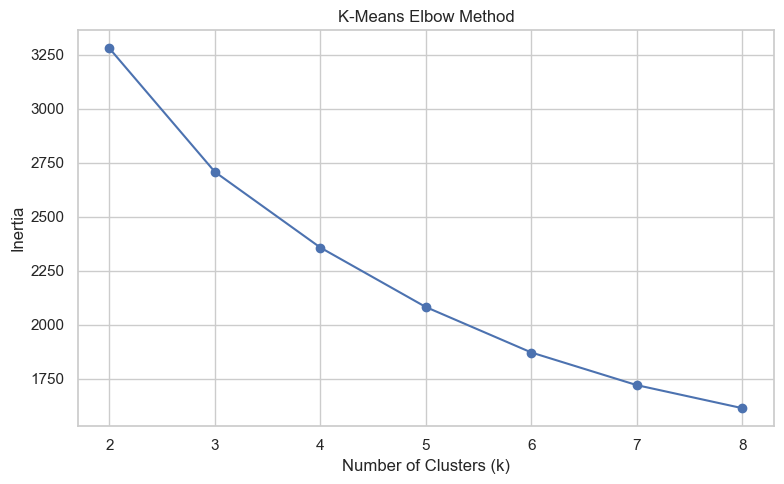

In [8]:
plt.figure(figsize=(8,5)); plt.plot(list(k_values), inertias, marker="o"); plt.title("K-Means Elbow Method"); plt.xlabel("Number of Clusters (k)"); plt.ylabel("Inertia"); plt.xticks(list(k_values)); plt.tight_layout(); plt.show()

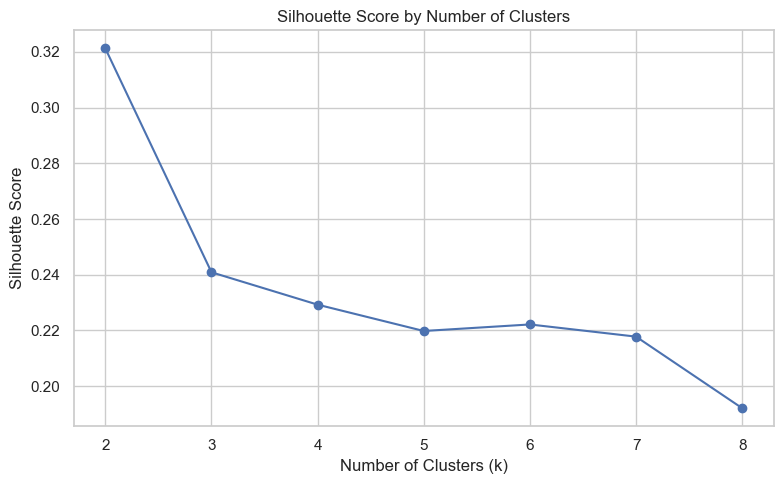

Selected k: 2


In [9]:
plt.figure(figsize=(8,5)); plt.plot(list(k_values), silhouette_scores, marker="o"); plt.title("Silhouette Score by Number of Clusters"); plt.xlabel("Number of Clusters (k)"); plt.ylabel("Silhouette Score"); plt.xticks(list(k_values)); plt.tight_layout(); plt.show()
best_k=int(cluster_evaluation.loc[cluster_evaluation["Silhouette_Score"].idxmax(),"k"])
print("Selected k:", best_k)

In [10]:
kmeans=KMeans(n_clusters=best_k, random_state=42, n_init=10)
customer_features["Cluster"]=kmeans.fit_predict(X_scaled)
final_silhouette=silhouette_score(X_scaled, customer_features["Cluster"])
print(f"Final silhouette score: {final_silhouette:.4f}")
cluster_profile=customer_features.groupby("Cluster").agg(
    Customers=("Customer_Name","count"),
    Avg_Recency=("Recency","mean"),
    Avg_Frequency=("Frequency","mean"),
    Avg_Monetary=("Monetary","mean"),
    Avg_Profit=("Total_Profit","mean"),
    Avg_Discount=("Avg_Discount","mean"),
    Avg_Quantity=("Total_Quantity","mean")
).round(2)
display(cluster_profile)

Final silhouette score: 0.3212

C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Profit,Avg_Discount,Avg_Quantity
Cluster,,,,,,,
0,565,279.35,5.19,11817.09,702.57,0.05,190.57
1,230,122.13,11.24,35821.51,4890.49,0.05,465.67


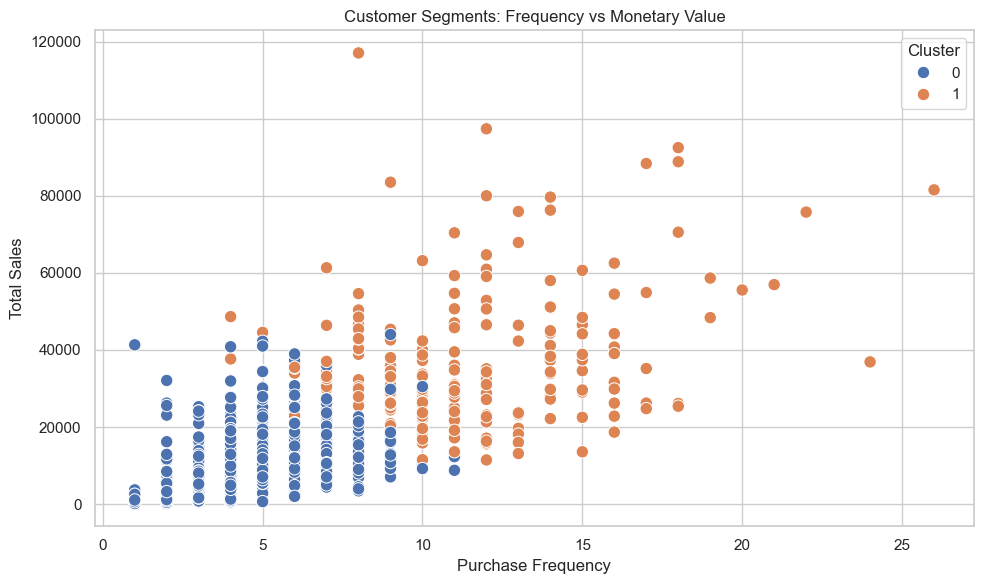

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=customer_features,x="Frequency",y="Monetary",hue="Cluster",s=80)
plt.title("Customer Segments: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency"); plt.ylabel("Total Sales"); plt.tight_layout(); plt.show()

### Segment Interpretation

Interpret clusters from the generated `cluster_profile`. Typical labels may include High-Value/Loyal, Potential Loyal, At-Risk, and Low-Value/Inactive. Do not assign labels until the numerical profiles have been inspected.

## 5. Predictive Modeling — Sales Prediction

In [12]:
model_df=df.copy()
model_df["Order_Year"]=model_df["Order_Date"].dt.year
model_df["Order_Month"]=model_df["Order_Date"].dt.month
model_df["Order_DayOfWeek"]=model_df["Order_Date"].dt.dayofweek
candidate_features=["Order_Quantity","Discount","Unit_Price","Shipping_Cost","Product_Base_Margin","Order_Year","Order_Month","Order_DayOfWeek"]
features=[c for c in candidate_features if c in model_df.columns]
model_data=model_df[features+["Sales"]].dropna()
X=model_data[features]; y=model_data["Sales"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
print("Features:",features); print("Training rows:",len(X_train)); print("Testing rows:",len(X_test))

Features: ['Order_Quantity', 'Discount', 'Unit_Price', 'Shipping_Cost', 'Product_Base_Margin', 'Order_Year', 'Order_Month', 'Order_DayOfWeek']
Training rows: 6719
Testing rows: 1680


In [13]:
linear_model=LinearRegression(); linear_model.fit(X_train,y_train)
linear_pred=linear_model.predict(X_test)
linear_mae=mean_absolute_error(y_test,linear_pred)
linear_rmse=np.sqrt(mean_squared_error(y_test,linear_pred))
linear_r2=r2_score(y_test,linear_pred)
print("Linear Regression"); print(f"MAE: {linear_mae:.2f}"); print(f"RMSE: {linear_rmse:.2f}"); print(f"R²: {linear_r2:.4f}")

Linear Regression
MAE: 1288.27
RMSE: 2289.64
R²: 0.4387


In [14]:
rf_model=RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)
rf_mae=mean_absolute_error(y_test,rf_pred)
rf_rmse=np.sqrt(mean_squared_error(y_test,rf_pred))
rf_r2=r2_score(y_test,rf_pred)
print("Random Forest"); print(f"MAE: {rf_mae:.2f}"); print(f"RMSE: {rf_rmse:.2f}"); print(f"R²: {rf_r2:.4f}")

Random Forest
MAE: 102.62
RMSE: 490.47
R²: 0.9742


In [15]:
model_comparison=pd.DataFrame({"Model":["Linear Regression","Random Forest"],"MAE":[linear_mae,rf_mae],"RMSE":[linear_rmse,rf_rmse],"R2":[linear_r2,rf_r2]})
display(model_comparison.round(4))
best_model_name=model_comparison.loc[model_comparison["RMSE"].idxmin(),"Model"]
print("Best model based on lowest RMSE:",best_model_name)

,Model,MAE,RMSE,R2
0,Linear Regression,1288.2699,2289.6444,0.4387
1,Random Forest,102.6161,490.4689,0.9742


Best model based on lowest RMSE: Random Forest


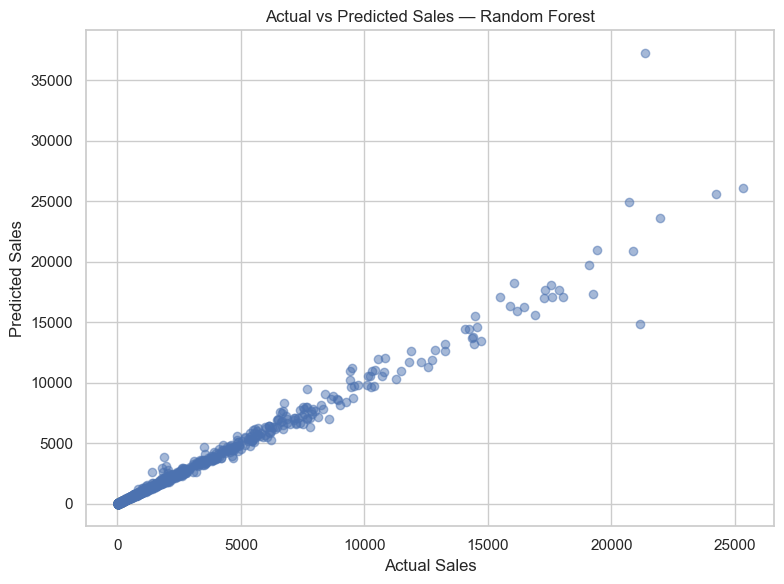

In [16]:
best_predictions=rf_pred if best_model_name=="Random Forest" else linear_pred
plt.figure(figsize=(8,6)); plt.scatter(y_test,best_predictions,alpha=0.5); plt.xlabel("Actual Sales"); plt.ylabel("Predicted Sales"); plt.title(f"Actual vs Predicted Sales — {best_model_name}"); plt.tight_layout(); plt.show()

,Feature,Importance
2,Unit_Price,0.7431
0,Order_Quantity,0.2315
1,Discount,0.0140
6,Order_Month,0.0032
7,Order_DayOfWeek,0.0029
4,Product_Base_Margin,0.0024
3,Shipping_Cost,0.0017
5,Order_Year,0.0013


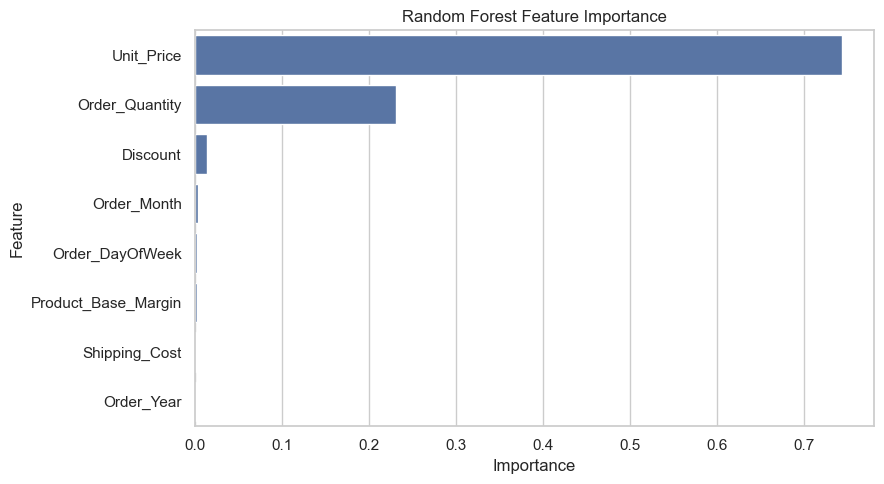

In [17]:
feature_importance=pd.DataFrame({"Feature":features,"Importance":rf_model.feature_importances_}).sort_values("Importance",ascending=False)
display(feature_importance.round(4))
plt.figure(figsize=(9,5)); sns.barplot(data=feature_importance,x="Importance",y="Feature"); plt.title("Random Forest Feature Importance"); plt.tight_layout(); plt.show()

## 6. Business Insights & Recommendations

- Identify the cluster with the highest monetary value and purchase frequency.
- Target valuable but recently inactive customers with retention campaigns.
- Use customer clusters for differentiated marketing offers.
- Compare Linear Regression and Random Forest using MAE, RMSE, and R².
- Prefer lower-error models while considering interpretability.
- Use feature importance to identify predictive variables; it does not prove causation.
- Use sales predictions to support sales planning and inventory decisions.

In [18]:
# Export Task 4 outputs
customer_features.to_csv("Task4_Customer_Segments.csv",index=False)
cluster_profile.to_csv("Task4_Cluster_Profile.csv")
cluster_evaluation.to_csv("Task4_Cluster_Evaluation.csv",index=False)
model_comparison.to_csv("Task4_Model_Comparison.csv",index=False)
feature_importance.to_csv("Task4_Feature_Importance.csv",index=False)
statistical_summary.to_csv("Task4_Statistical_Summary.csv")
print("All Task 4 output CSV files saved successfully.")

All Task 4 output CSV files saved successfully.


## Task 4 Completion Checklist

- [x] Statistical analysis
- [x] Hypothesis testing
- [x] RFM-style customer features
- [x] K-Means clustering
- [x] Elbow Method
- [x] Silhouette Score
- [x] Cluster profiling
- [x] Sales prediction
- [x] Linear Regression
- [x] Random Forest
- [x] MAE / RMSE / R²
- [x] Feature importance
- [x] Business recommendations
- [x] Exportable output files